In [7]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.bandit_task import BanditTaskNeuroPixelsDataset
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model, project_into_latent_space
from ncmcm.bundlenet.utils import prep_data
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.visualisers.latent_space import LatentSpaceVisualiser
from sklearn.preprocessing import LabelEncoder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Dataset Overview

We apply **BunDLe-Net** to Neuropixels recordings from rat medial prefrontal cortex (mPFC) during a two-arm bandit task. This dataset demonstrates BunDLe-Net's capability to:
- Handle high-dimensional spike train data from hundreds of neurons
- Learn latent representations of decision-making processes
- Capture behavioral state transitions during a cognitive task

### The Two-Arm Bandit Task

In this task, rats make sequential choices between two options (left/right arms) to maximize reward. The behavioral states include:

- **Intertrial**: Period between trials
- **Hold**: Preparatory state before choice initiation
- **Choosing left**: Active decision period (movement toward left choice)
- **Choosing right**: Active decision period (movement toward right choice)
- **Reward**: Successful trial outcome
- **No reward**: Unsuccessful trial outcome

### Loading the Data

We use the `BanditTaskNeuroPixelsDataset` class to load and preprocess the data. This class:
- Loads spike times from Neuropixels recordings
- Synchronizes neural data with behavioral timestamps
- Downsamples and bins spike data
- Applies optional state transitions (e.g., merging "hold" and "choosing" into combined states)

The data is formatted as:
- **x**: Neuronal spike data, shape = (neurons, timepoints), stored as sparse matrix
- **b**: Behavioral state labels, shape = (1, timepoints), stored as sparse matrix
- **b_labels_dict**: Dictionary mapping state IDs to state names

Dataset cached to: ../datasets/raw/twoArmBandit/JPAS_0023_20230922/BanditTaskNeuroPixelsDataset/fs20_count_all_normminmax_global_d202e388.pkl
Loaded BanditTaskNeuroPixelsDataset from ../datasets/raw/twoArmBandit/JPAS_0023_20230922
Neuronal data shape: (575, 25863), Behavioral data shape: (1, 25863), Sampling frequency: 19.999288481238988 Hz
Behavioral labels: {0: 'intertrial', 1: 'hold', 2: 'reward', 3: 'no reward', 4: 'choosing left', 5: 'choosing right'}
Neuronal data shape: (25863, 575)
Behavioral data shape: (25863,)
Behavioral labels: {0: 'intertrial', 1: 'hold', 2: 'reward', 3: 'no reward', 4: 'choosing left', 5: 'choosing right'}
Recording length: 21.55 minutes
Sampling frequency: 19.999288481238988 Hz


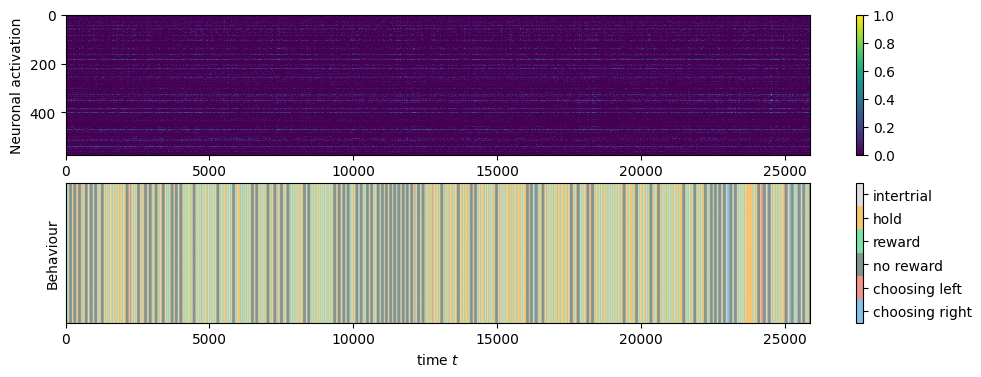

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [8]:
# Load bandit task data
data_path = '../datasets/raw/twoArmBandit/JPAS_0023_20230922'

dataset = BanditTaskNeuroPixelsDataset(
    data_path=data_path,
    downsample_fs=20,  # Downsample to 20 Hz
    downsample_method='count',  # Count spikes per bin
    good_neurons_only=False,  # Include all neurons
    normalize_method='minmax_global'  # Min-max normalization across all neurons
)

# Extract neuronal and behavioral data
x = dataset.x.toarray().T  # Convert sparse to dense and transpose to (neurons, time)
b = dataset.b.toarray().flatten()  # Convert sparse to dense and flatten to 1D

print(f"Neuronal data shape: {x.shape}")
print(f"Behavioral data shape: {b.shape}")
print(f"Behavioral labels: {dataset.b_labels_dict}")
print(f"Recording length: {dataset.get_recording_length_mins():.2f} minutes")
print(f"Sampling frequency: {dataset.fs} Hz")

# Plot neuronal and behavioral data overview
plotting_neuronal_behavioural(
    x,
    b=b,
    b_names=dataset.b_labels_dict,
    b_colors=dataset.get_color_map_for_plotting(),
    show_fig=True
)

## Preparing Data for BunDLe-Net

Ensure that your discrete behavioral labels are consecutive integers from `0` to `n_states - 1`. The `BanditTaskNeuroPixelsDataset` already relabels states, but we use `LabelEncoder` for consistency:

In [9]:
label_encoder = LabelEncoder()
b_encoded = label_encoder.fit_transform(b)

The **`prep_data`** function transforms the time-series neural activity (`x`) and behavioral (`b`) data into a format suitable for the **BunDLe-Net** model. The **`win`** parameter specifies the window length for time delay embedding:

- **`win=1`**: Embeds a single time step
- **`win>1`**: Embeds a window of time-slices to capture temporal dependencies

#### Output Shapes
- **Neuronal data (`x_`)**: Shaped as **(t - win, 2, win, n)**, where:
  - `x_[:,0,:,:]` represents $X_t$
  - `x_[:,1,:,:]` represents $X_{t+1}$
  - The first dimension denotes time-steps
  - The last dimension denotes feature number (neuron number)
- **Behavioral data (`b_`)**: Shaped as **(t - win,)** to maintain synchronization with `x_`

For this dataset, we use a window of 50 time steps (≈2.5 seconds at 20 Hz) to capture the temporal structure of decision-making:

In [10]:
print(f"Original shapes: x={x.shape}, b={b_encoded.shape}")
x_, b_ = prep_data(x, b_encoded, win=50)
print(f"Prepared shapes: x_={x_.shape}, b_={b_.shape}")

Original shapes: x=(25863, 575), b=(25863,)
Prepared shapes: x_=(25813, 2, 50, 575), b_=(25813,)


## Training BunDLe-Net

Now, train BunDLe-Net on the prepared time-series neural activity and behavioral data. We use:
- **latent_dim=3**: Three-dimensional latent space for visualization
- **gamma=0.75**: Weight balancing Markovian loss and behavioral prediction loss
- **learning_rate=0.00005**: Adam optimizer learning rate
- **n_epochs=500**: Number of training epochs

In [11]:
model = BunDLeNet(
    latent_dim=3,
    num_behaviour=len(dataset.b_labels_dict),
    input_shape=x_.shape
)

loss_array, _ = train_model(
    x_,
    b_,
    model,
    b_type='discrete',
    gamma=0.75,
    learning_rate=0.00005,
    n_epochs=500
)

Loss [Markov, Behaviour, Total]: [0.0116 0.0068 0.0184]: 100%|██████████| 500/500 [07:23<00:00,  1.13it/s]


## Training Loss vs Epochs

We plot the losses over the epochs to check whether the model has converged during training. The three loss components are:
- **Markovian loss**: Encourages smoothness in latent trajectories
- **Behavioral loss**: Ensures behavioral states are predictable from latent states
- **Total loss**: Weighted combination of both losses

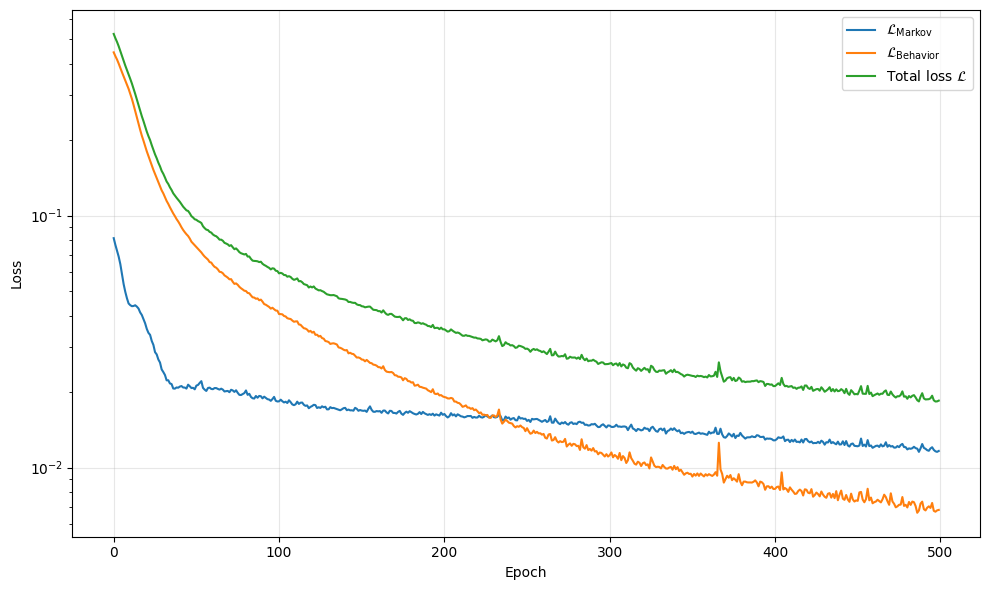

In [12]:
plt.figure(figsize=(10, 6))
for i, label in enumerate([
    r"$\mathcal{L}_{\mathrm{Markov}}$",
    r"$\mathcal{L}_{\mathrm{Behavior}}$",
    r"Total loss $\mathcal{L}$"
]):
    plt.semilogy(loss_array[:, i], label=label)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Projecting into Latent Space

Once we confirm the model has converged, we project the neural traces into the learned latent space:

In [13]:
y0_ = project_into_latent_space(x_, model)

## Visualizing the Embedding

Using the `LatentSpaceVisualiser` class, we visualize the latent space. We use the custom color scheme defined in the dataset for consistency with the behavioral states.

In [14]:
vis = LatentSpaceVisualiser(
    y0_,
    b_,
    dataset.b_labels_dict,
    colors=dataset.get_rgb_colors_for_visualizer()
)

### Latent Time Series

First, visualize the embedding as time series to see how the latent dimensions correspond to behavioral states:

In [19]:
vis.plot_latent_timeseries_plotly(
    filename='../figures/latent_time_series_bandit_task.png',
    show_fig=True
)

### Phase Space Dynamics

Next, explore the temporal dynamics in phase space (state space). This visualization plots arrows between time points at $t$ and $t+1$, helping identify temporal structures and decision-making trajectories:

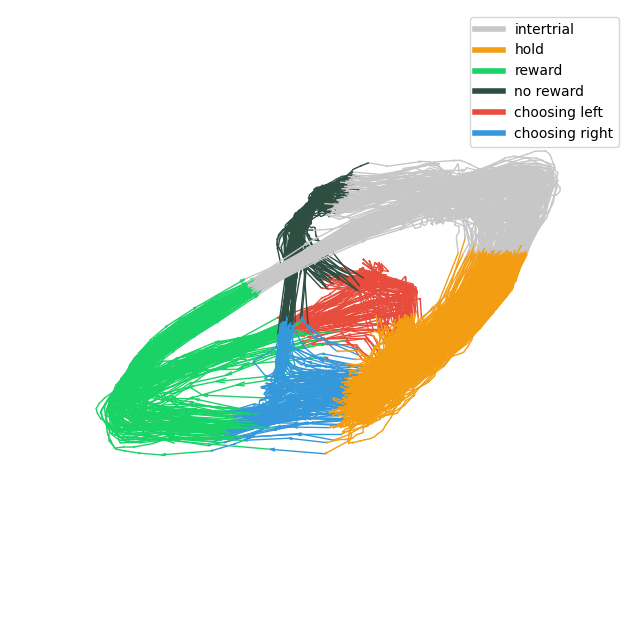

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [16]:
%matplotlib inline
vis.plot_phase_space(
    filename='../figures/phase_space_dynamics_bandit_task.png',
    show_fig=True
)

### 3D Rotating Visualization

Create a rotating 3D plot to better visualize the latent space structure and decision-making trajectories:

MovieWriter imagemagick unavailable; using Pillow instead.


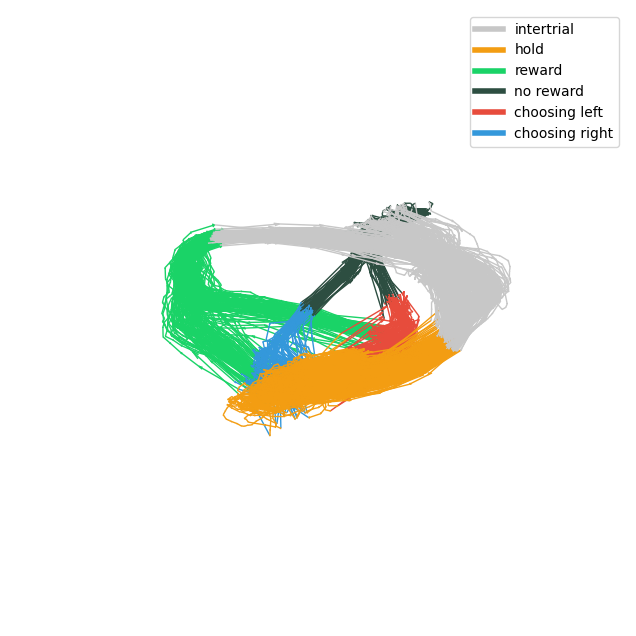

(<Figure size 800x800 with 1 Axes>, <Axes3D: >)

In [17]:
%matplotlib inline
vis.rotating_plot(
    filename='../figures/rotation_bandit_task.gif',
    show_fig=True
)

### Recurrence Plot Analysis

Analyze the recurrence structure in the latent space. Points that are close in the latent space (within a threshold) are marked, revealing repeated behavioral patterns and decision-making motifs:

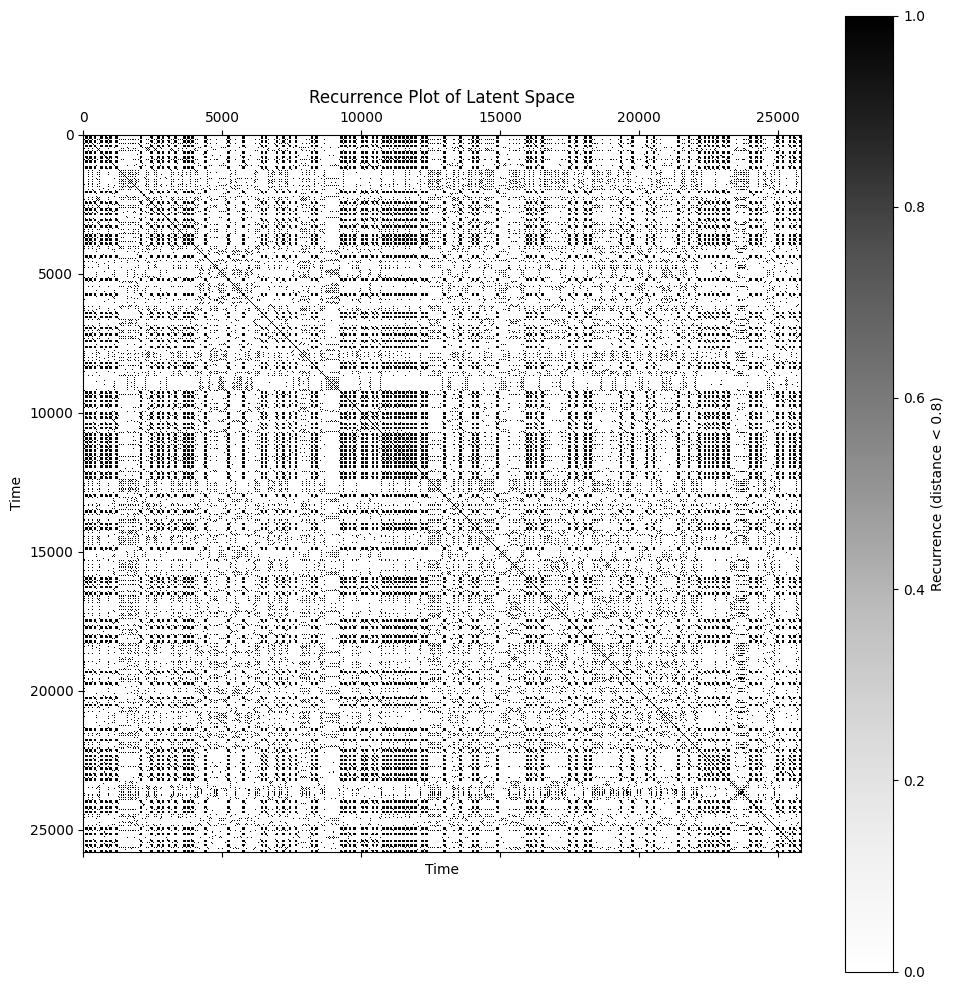

In [18]:
%matplotlib inline
# Compute pairwise distances in latent space
pd_y = np.linalg.norm(y0_[:, np.newaxis] - y0_, axis=-1) < 0.8

plt.figure(figsize=(10, 10))
plt.matshow(pd_y, cmap='Greys', fignum=0)
plt.title('Recurrence Plot of Latent Space')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence (distance < 0.8)')
plt.tight_layout()
plt.show()

## Summary

In this demo, we:
1. Loaded Neuropixels spike data from a two-arm bandit task using `BanditTaskNeuroPixelsDataset`
2. Downsampled the data to 20 Hz with global min-max normalization
3. Prepared the data with a 50-timestep window for temporal embedding
4. Trained BunDLe-Net to learn a 3D latent representation of decision-making dynamics
5. Visualized the latent space using time series, phase space, and 3D rotating plots
6. Analyzed recurrence patterns to identify repeated behavioral motifs

The learned latent space reveals the temporal structure of decision-making, with clear trajectories corresponding to different behavioral states and choice outcomes.